# EDA — S&P 500 daily OHLCV panel (2016-2026)

Data source: yfinance (Kaggle's camnugent/sandp500 was the original plan, but no Kaggle credentials were available; yfinance covers the same universe with longer, current history and needs no auth). 499 of 503 current S&P 500 tickers have enough history; 4 recent additions were dropped for having under 500 rows.

**MLU concept applied:** before any modeling, check the target's basic statistical properties (class balance, autocorrelation) — this is the tabular-data EDA step MLU emphasizes before jumping to feature engineering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/sp500_panel.csv', parse_dates=['date'])
df = df.sort_values(['Ticker', 'date']).reset_index(drop=True)
print(f"{len(df):,} rows, {df['Ticker'].nunique()} tickers, {df['date'].min().date()} to {df['date'].max().date()}")
df.isna().sum()

Matplotlib is building the font cache; this may take a moment.


1,283,402 rows, 499 tickers, 2016-01-04 to 2026-06-29


date      0
Ticker    0
open      1
high      1
low       1
close     1
volume    0
dtype: int64

## Why direction, not price level

Compare the lag-1 autocorrelation of the raw closing price vs. daily returns. If price level is ~1.0 autocorrelated, a model "predicting" price is really just echoing yesterday's value — not learning anything.

In [2]:
df['ret'] = df.groupby('Ticker')['close'].pct_change()

sample_tickers = ['AAPL', 'MSFT', 'JPM', 'XOM', 'KO']
rows = []
for t in sample_tickers:
    sub = df[df['Ticker'] == t].set_index('date')
    rows.append({
        'ticker': t,
        'price_level_autocorr_lag1': round(sub['close'].autocorr(1), 4),
        'daily_return_autocorr_lag1': round(sub['ret'].autocorr(1), 4),
    })
autocorr_df = pd.DataFrame(rows)
autocorr_df

,ticker,price_level_autocorr_lag1,daily_return_autocorr_lag1
0,AAPL,0.9995,-0.0595
1,MSFT,0.9995,-0.1351
2,JPM,0.9995,-0.0917
3,XOM,0.9991,-0.0236
4,KO,0.9991,-0.0322


**Finding:** raw price level is ~0.999 autocorrelated (trivially predictable, but useless — it's just yesterday's price). Daily returns are close to zero autocorrelation (slightly negative), consistent with the efficient-market/random-walk expectation. This confirms the project's design choice: predict **direction of next-day return**, never raw price.

## Class balance — the naive baseline to beat

Pooled pct of up-days: 0.5237
Majority-class naive baseline accuracy: 0.5237


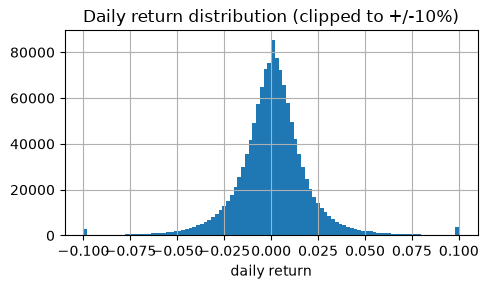

In [3]:
df['direction'] = (df['ret'] > 0).astype(int)
up_rate = df['direction'].mean()
print(f"Pooled pct of up-days: {up_rate:.4f}")
print(f"Majority-class naive baseline accuracy: {max(up_rate, 1 - up_rate):.4f}")

fig, ax = plt.subplots(figsize=(5, 3))
df['ret'].clip(-0.1, 0.1).hist(bins=100, ax=ax)
ax.set_title('Daily return distribution (clipped to +/-10%)')
ax.set_xlabel('daily return')
fig.tight_layout()
fig.savefig('return_distribution.png', dpi=100)
plt.show()

**Finding:** ~52.4% of pooled daily observations are up-days — close to a coin flip but not exactly balanced, so the naive baselines the model must beat are: (a) majority-class predictor at ~52.4% accuracy, and (b) "same direction as yesterday" (persistence) baseline, computed in the modeling notebook. Any model that can't clear both, on the held-out chronological test set, isn't adding value.

## Summary of EDA findings
- 499 S&P 500 tickers, ~1.28M pooled daily rows, 2016-01 to 2026-06.
- Negligible missing data (a handful of rows dropped for missing OHLC).
- Price level is near-random-walk (autocorr ~0.999 but meaningless); returns are ~uncorrelated day-to-day — direction/return prediction is the only defensible target.
- Class balance is close to 50/50 (52.4% up) — sets the majority-class naive baseline for Phase 3.